# 🤖 OpenAI APIs with LangChain — Complete Guide

## What You Will Learn
This notebook covers:
- ✅ Calling **GPT-4o** using LangChain's `ChatOpenAI`
- ✅ Generating images using **DALL·E 3**
- ✅ Transcribing audio using **Whisper**
- ✅ **Function Calling** and structured output extraction
- ✅ **Token counting** and managing long inputs
- ✅ **Lab: Build a Q&A Bot** using ChatGPT API with memory

---
## Prerequisites
- An **OpenAI API Key** (get it from https://platform.openai.com)
- Python 3.9+
- Libraries: `langchain`, `langchain-openai`, `langchain-core`, `openai`, `tiktoken`

## 📦 Section 0 — Install Required Libraries

We install:
- `langchain` — the core orchestration framework
- `langchain-openai` — OpenAI-specific integrations (ChatOpenAI, OpenAIEmbeddings)
- `langchain-core` — base classes like `ChatPromptTemplate`, `HumanMessage`
- `openai` — direct OpenAI SDK (used for DALL·E, Whisper)
- `tiktoken` — OpenAI's tokenizer for counting tokens

## 🔑 Section 0.1 — Load Your API Key

Your API key identifies who is making the request to OpenAI.  
We load it from a  file using  — **never hardcode it in the notebook**.

**Your  file** (in the project root) should contain:


**Why ?**
- The  file is listed in  — never committed to git
- Safe to share the notebook without exposing your key
- One key file serves all notebooks in the project

Run the cell below to load the key into the environment:

In [1]:
from dotenv import load_dotenv
import os

# we have to add load_dotenv() it will read all values from .env file and load to environment variable
load_dotenv()

# check if api key is loaded
bool(os.getenv("OPENAI_API_KEY"))

True

---
## 💬 Section 1 — GPT-4o with LangChain's ChatOpenAI

### 📌 What is GPT-4o?
GPT-4o is OpenAI's **most capable multimodal model**. It understands text, images, and audio.  
In this section we use it for **text-based conversations**.

### 🏢 Real-World Use Case: Customer Support Auto-Reply
Imagine you run an **e-commerce company** like Amazon or Flipkart.  
Thousands of customers email every day asking:  
> *"Where is my order?"*, *"How do I return this product?"*, *"I got a damaged item."*

Instead of hiring a large support team, you can feed the customer's email to GPT-4o and get a **professional, helpful reply drafted instantly**.

### 🔧 How LangChain Helps
LangChain's `ChatOpenAI` wraps the raw OpenAI API call, so you can:
- Switch models easily (gpt-4o → gpt-3.5-turbo) with one line change
- Chain prompts together
- Add memory, tools, and agents later

### 📐 Key Parameters
| Parameter | Meaning | Example |
|---|---|---|
| `model` | Which GPT model to use | `gpt-4o` |
| `temperature` | Creativity level (0=focused, 1=creative) | `0.7` |
| `max_tokens` | Max words in response | `500` |

In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

# Initialize the GPT-4o model
# temperature=0.7 means moderately creative responses
llm = ChatOpenAI(model="gpt-4o", temperature=0.7)

# Define the conversation:
# SystemMessage = instructions/role for the AI
# HumanMessage  = what the user/customer is asking
messages = [
    SystemMessage(content="You are a professional customer support agent for an e-commerce platform. Be polite, empathetic, and provide clear solutions."),
    HumanMessage(content="Hi, I ordered a mobile phone 5 days ago but haven't received it yet. My order ID is #45678. Can you help?")
]

# Make the API call
response = llm.invoke(messages)

print("📧 Auto-Generated Customer Reply:")
print("-" * 50)
print(response.content)

📧 Auto-Generated Customer Reply:
--------------------------------------------------
Hello! I'm sorry to hear that you haven't received your mobile phone yet. I understand how important it is to get your order on time. Let me look into this for you right away.

I see your order ID is #45678. Please give me a moment to check the status of your shipment.

[Checking order status…]

Thank you for waiting. It appears that your order was shipped out on time, but there seems to be a delay with the courier. I apologize for any inconvenience this may have caused. The current status indicates that your package is in transit and should arrive within the next 2-3 business days.

To ensure you receive your order as soon as possible, I'll keep monitoring the shipment and provide you with any updates. Additionally, I'll be happy to escalate this to our logistics team to see if there's anything further we can do to expedite the delivery.

If you have any more questions or need further assistance, pleas

In [3]:
print("-" * 50)
api_cost_per_1000_token = 0.005
total_token = response.usage_metadata["total_tokens"]
print(f"{total_token=}")
cost = (total_token/1000) * api_cost_per_1000_token
print(f"total cost api cost: ${cost}")
print("-" * 50)
cached = response.response_metadata['token_usage']['prompt_tokens_details']['cached_tokens']
print(f"Cached tokens: {cached}")  # 0 = no cache hit, >0 = saved money

--------------------------------------------------
total_token=263
total cost api cost: $0.001315
--------------------------------------------------
Cached tokens: 0


### 1.1 — Using ChatPromptTemplate (Reusable Prompts)

`ChatPromptTemplate` from `langchain_core` lets you create **reusable prompt templates** — like a **form with blank fields** you fill in each time.

Instead of rewriting the whole prompt for every customer, you define a template once and just change the variable `{complaint}` each time.

In [4]:
from langchain_core.prompts import ChatPromptTemplate

# Define a reusable prompt template
# {complaint} is a variable — filled in at runtime
prompt_template = ChatPromptTemplate([
    ("system", "You are a professional customer support agent for an e-commerce platform. Be polite, empathetic, and provide clear solutions."),
    ("human", "{complaint}")])
# Build a chain: prompt → llm
# The pipe operator | chains components together
chain = prompt_template | llm

# Invoke with different complaints
user_complaint = {"complaint": "I received only phone box. could you please replace me with a new phone."}
result = chain.invoke(user_complaint)

print("📧 Auto-Generated Reply for Broken Item Complaint:")
print("-" * 50)
print(result.content)

📧 Auto-Generated Reply for Broken Item Complaint:
--------------------------------------------------
I'm really sorry to hear that you've only received the phone box. I understand how disappointing this must be. Let's get this resolved for you as quickly as possible.

Could you please provide me with your order number and any photos of the package you received? This will help us investigate the issue with our shipping department. Once we have this information, we can proceed with arranging a replacement phone for you.

Thank you for your patience and understanding.


In [5]:
print("-" * 50)
cost_per_1000_token = 0.005
total_tokens = result.usage_metadata["total_tokens"]
cost = (total_tokens/1000) * cost_per_1000_token
print(f"total cost for API call: ${cost}")

--------------------------------------------------
total cost for API call: $0.0006900000000000001


---
## 🎨 Section 2 — DALL·E 3: Image Generation

### 📌 What is DALL·E?
DALL·E is OpenAI's **text-to-image model**.  
You give it a text description (called a **prompt**), and it generates a brand new image.

### 🏢 Real-World Use Case: E-commerce Product Banner Generator
Imagine you sell products on a website and need to create **promotional banners** for every new product.  
Hiring a designer costs time and money.  
With DALL·E, you describe the banner and get an image in **seconds**.

> Example prompt: *"A modern promotional banner for a wireless Bluetooth headphone, blue gradient background, product in center, minimalist style"*

### ⚠️ Note
DALL·E is accessed via the **direct OpenAI SDK** (not LangChain) because LangChain's image generation integration is still evolving.  
We use `openai.OpenAI()` client directly here.

### 📐 Key Parameters
| Parameter | Meaning | Options |
|---|---|---|
| `model` | Which DALL·E version | `dall-e-3`, `dall-e-2` |
| `prompt` | Text description of the image | Any string |
| `size` | Image dimensions | `1024x1024`, `1792x1024` |
| `quality` | Image quality | `standard`, `hd` |
| `n` | Number of images | `1` (DALL·E 3 only supports 1) |

Image saved as generated_banner.png


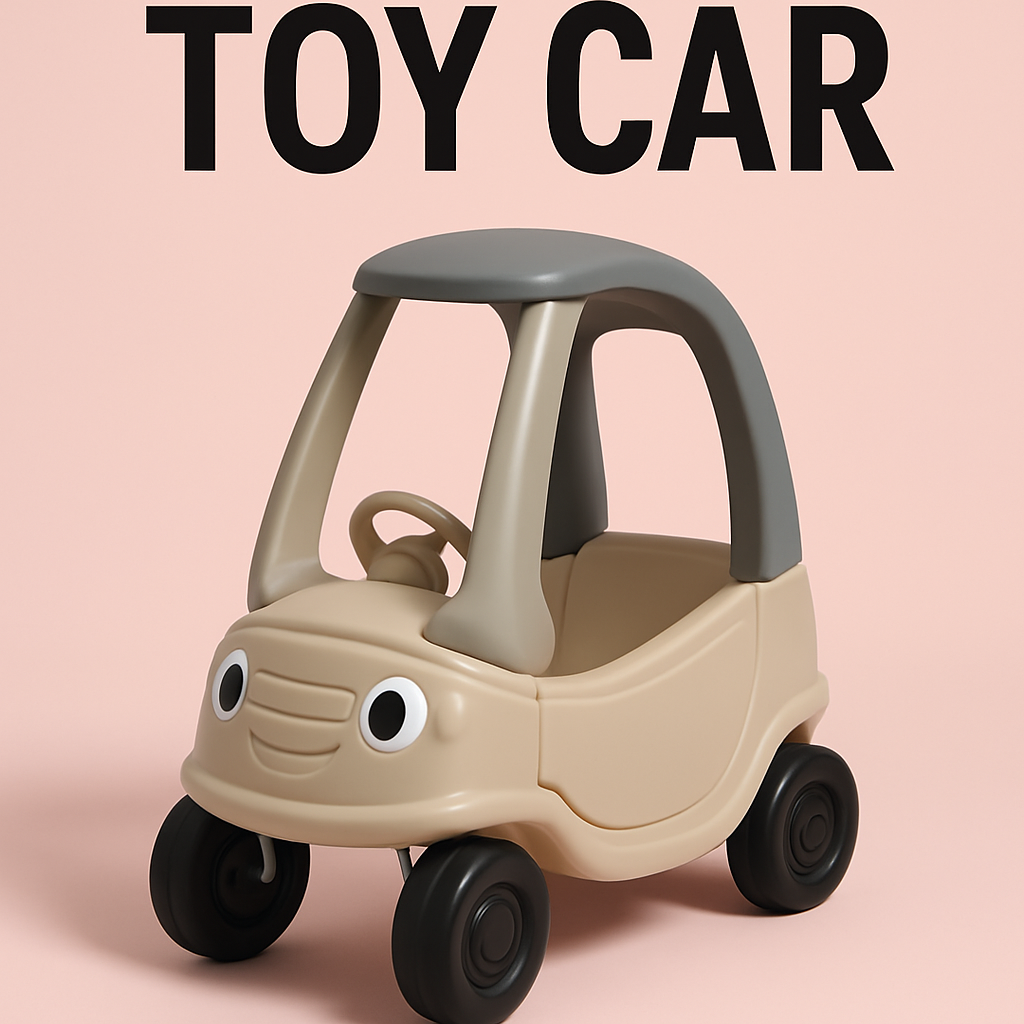

In [6]:
from openai import OpenAI
from IPython.display import Image, display

# Initialize the OpenAI client
# client.images.generate() is used directly (not via LangChain)
# because LangChain image generation support is still evolving
client = OpenAI()

# Define the image prompt
# Be descriptive — the more detail, the better the result
image_prompt = (
    "a modern promotional banner for toddler toy car. light pink in background. product in the center. toy car text on top of image."
)

# gpt-image-1 is OpenAI latest image model (replaces dall-e-3 in SDK v2+)
# Parameters:
#   size    : "1024x1024" | "1536x1024" | "1024x1536"
#   quality : "low" | "medium" | "high"  (gpt-image-1 uses low/medium/high)
#   n       : number of images (1-10)
response = client.images.generate(
    model="gpt-image-1",
    prompt=image_prompt,
    size="1024x1024",
    quality="medium",
    n=1
)

# gpt-image-1 returns base64-encoded image data (not a URL like dall-e-3)
import base64
from PIL import Image as PILImage
import io

image_b64 = response.data[0].b64_json
image_bytes = base64.b64decode(image_b64)

# Display the image inside the notebook
img = PILImage.open(io.BytesIO(image_bytes))
img.save("generated_banner.png")  # save locally
print("Image saved as generated_banner.png")
display(img)

---
## 🎙️ Section 3 — Whisper: Audio Transcription

### 📌 What is Whisper?
Whisper is OpenAI's **speech-to-text model**.  
It converts spoken audio (MP3, WAV, M4A etc.) into written text — like an automated transcriptionist.

It supports **100+ languages** and can handle accents, background noise, and technical vocabulary.

### 🏢 Real-World Use Case: Meeting Notes Transcriber
Your team has a 1-hour project meeting. Instead of someone manually writing notes:  
1. Record the meeting audio
2. Feed the audio file to Whisper
3. Get a **full transcript** in seconds
4. Then optionally pass the transcript to GPT-4 to generate a **summary with action items**

This is exactly how tools like **Otter.ai, Fireflies.ai, and Zoom's AI companion** work internally.

### 📁 How to Use
- You need an audio file (`.mp3`, `.wav`, `.m4a`, `.mp4`, `.webm`)
- Max file size: **25 MB**
- We use `client.audio.transcriptions.create()`

### ⚠️ For This Demo
Replace `"your_audio_file.mp3"` with a real audio file path on your machine.

In [12]:
from openai import OpenAI
import os
from pydub  import AudioSegment
client = OpenAI()

# -------------------------------------------------------
# DEMO MODE: Creating a dummy audio file for demonstration
# In real usage: replace audio_file_path with your .mp3 file
# -------------------------------------------------------
audio_file_path = "Planning Meeting Audio 2026-4-30.mp3"  # Replace with your actual file

# Check if file exists before calling the API
if not os.path.exists(audio_file_path):
    print("⚠️  Audio file not found!")
    print("📌 How to use Whisper:")
    print("   1. Record a short audio clip (your voice, a meeting snippet etc.)")
    print("   2. Save it as 'meeting_recording.mp3' in the same folder as this notebook")
    print("   3. Re-run this cell")
    print()
    print("📋 Code that will run when file is present:")
    print("""
    with open(audio_file_path, "rb") as audio_file:
        transcript = client.audio.transcriptions.create(
            model="whisper-1",
            file=audio_file,
            language="en"   # Optional: specify language
        )
    print(transcript.text)
    """)
else:
    # Actual Whisper API call
    audio = AudioSegment.from_mp3(audio_file_path)
    compressed_path = "compressed_meeting.mp3"
    audio.export(compressed_path, format="mp3", bitrate="64k")  # reduce bitrate
    
    print(f"Original Size: {os.path.getsize(audio_file_path)/1024/1024:.2f} MB")
    print(f"Compresed Size: {os.path.getsize(compressed_path)/1024/1024:.2f} MB")


    with open(audio_file_path, "rb") as audio_file:
        transcript = client.audio.transcriptions.create(
            model="whisper-1",
            file=compressed_path,
            language="en"  # Specify language for better accuracy
        )

    print("🎙️ Transcription Result:")
    print("-" * 50)
    print(transcript.text)

FileNotFoundError: [WinError 2] The system cannot find the file specified

### 3.1 — Bonus: Transcribe + Summarize with GPT-4o

This shows the real power — **chain Whisper + GPT-4o** together:  
Audio → Transcript (Whisper) → Summary + Action Items (GPT-4o)

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# Simulated transcript (replace with actual transcript.text from Whisper above)
simulated_transcript = """
Alright team, let's get started. So we discussed the new product launch for next quarter.
Priya will handle the marketing deck by Friday. Raj needs to finalize the pricing strategy 
and send it to the team by Wednesday. We also agreed to set up a follow-up meeting next 
Monday at 10 AM. The engineering team said the MVP will be ready by end of the month.
Any blockers should be flagged to the project manager by tomorrow EOD.
"""

# Prompt template to summarize meeting transcript
summary_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert meeting assistant. Extract a clean summary and action items."),
    ("human", """
Here is the meeting transcript:

{transcript}

Please provide:
1. A 3-line summary of the meeting
2. A numbered list of action items with owner names and deadlines
""")
])

llm = ChatOpenAI(model="gpt-4o", temperature=0)
chain = summary_prompt | llm

result = chain.invoke({"transcript": simulated_transcript})

print("📋 Meeting Summary + Action Items:")
print("-" * 50)
print(result.content)

---
## 🔧 Section 4 — Function Calling & Output Structuring

### 📌 What is Function Calling?
Normally, GPT returns a **plain text answer**.  
But what if you need the output in a **structured format** like JSON — so your code can process it?

That's what **Function Calling** does.  
You define a **JSON schema** (like a template with field names and types), and GPT fills it in.

### 🏢 Real-World Use Case: Structured Data Extractor from Customer Emails
Your support team receives emails like:
> *"Hi, I'm Anitha from Chennai. I ordered a Samsung TV (Order #78901) on 15th March and it arrived damaged. I want a replacement."*

Instead of reading every email manually, you can use Function Calling to extract:
```json
{
  "customer_name": "Anitha",
  "city": "Chennai",
  "product": "Samsung TV",
  "order_id": "78901",
  "issue": "damaged",
  "request": "replacement"
}
```
This structured data can then be **directly inserted into your CRM or database**.

### 🔑 Key Concept: `.bind_tools()`
In the latest LangChain, we use `.bind_tools()` to attach a tool/function schema to the model.  
The model then knows it **must return data in that exact structure**.

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# Step 1: Define the function schema (the structured format we want)
# This tells GPT: "Extract these exact fields from the input"
extract_complaint_tool = {
    "name": "extract_complaint_details",
    "description": "Extract structured complaint details from a customer email.",
    "parameters": {
        "type": "object",
        "properties": {
            "customer_name": {
                "type": "string",
                "description": "Full name of the customer"
            },
            "city": {
                "type": "string",
                "description": "City where the customer is located"
            },
            "product_name": {
                "type": "string",
                "description": "Name of the product mentioned"
            },
            "order_id": {
                "type": "string",
                "description": "Order ID or reference number"
            },
            "issue_type": {
                "type": "string",
                "enum": ["damaged", "not_delivered", "wrong_item", "refund", "other"],
                "description": "Category of the complaint"
            },
            "resolution_requested": {
                "type": "string",
                "description": "What the customer wants (replacement, refund, etc.)"
            }
        },
        "required": ["customer_name", "product_name", "issue_type"]
    }
}

# Step 2: Bind the tool to the model
# tool_choice="any" forces the model to always use the tool
llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tool = llm.bind_tools([extract_complaint_tool], tool_choice="any")

# Step 3: Customer email to extract from
customer_email = """
Hi, my name is Anitha Krishnan and I'm writing from Chennai. 
I placed an order for a Samsung 55-inch Smart TV (Order #TN78901) on 10th April.
When it arrived yesterday, the screen had a big crack. This is completely unacceptable.
I want an immediate replacement or a full refund.
"""

# Step 4: Invoke the model
response = llm_with_tool.invoke([HumanMessage(content=customer_email)])

print("📥 Raw Response Type:", type(response))
print(response.content)

In [ ]:
import json

# Step 5: Parse the structured output from the tool call
# The response contains tool_calls — extract the arguments
tool_calls = response.tool_calls

if tool_calls:
    extracted_data = tool_calls[0]["args"]
    
    print("✅ Extracted Complaint Data (Structured JSON):")
    print("-" * 50)
    print(json.dumps(extracted_data, indent=2))
    
    print()
    print("💡 This JSON can now be directly inserted into your CRM database!")
else:
    print("No tool call was made.")

---
## 📊 Section 5 — Token Limits and Response Management

### 📌 What are Tokens?
OpenAI models don't read words — they read **tokens**.  
A token is roughly **¾ of a word** in English.

| Text | Approximate Tokens |
|---|---|
| `"Hello"` | 1 |
| `"Hello, how are you?"` | 5 |
| 1 page of text (~500 words) | ~700 tokens |
| This entire notebook | ~3000+ tokens |

### ⚠️ Why Token Limits Matter
Every GPT model has a **context window** — maximum tokens it can handle at once:
- `gpt-3.5-turbo` → **16,385 tokens**
- `gpt-4o` → **128,000 tokens**

If you send a 200-page PDF to GPT, it **won't fit**. You get an error.

### 🏢 Real-World Use Case: Long Document Summarizer
A law firm wants to summarize a 500-page contract.  
Strategy: **Split the document into chunks → summarize each chunk → combine summaries**.

This is called **Map-Reduce summarization**.

### 🔑 Tools Used
- `tiktoken` — counts tokens accurately
- `RecursiveCharacterTextSplitter` — splits long text into manageable chunks

In [ ]:
import tiktoken

# Load the tokenizer for GPT-4o (cl100k_base encoding)
# Different models use different encodings
encoder = tiktoken.get_encoding("cl100k_base")

# Sample texts to count tokens
sample_texts = [
    "Hello!",
    "How are you doing today?",
    "Artificial Intelligence is transforming every industry including healthcare, finance, and education.",
    "This is a long paragraph. " * 50  # Repeating to simulate a long document
]

print("📊 Token Count Examples:")
print("-" * 50)
for text in sample_texts:
    tokens = encoder.encode(text)
    display_text = text[:60] + "..." if len(text) > 60 else text
    print(f"Text: '{display_text}'")
    print(f"  → Token count: {len(tokens)}")
    print()

print("💡 Rule of thumb: 1 token ≈ 4 characters ≈ 0.75 words in English")

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# Simulated long document (legal contract excerpt)
long_document = """
SERVICE AGREEMENT CONTRACT

This Service Agreement ("Agreement") is entered into as of the 1st day of January 2024, 
by and between TechSolutions Pvt Ltd ("Service Provider"), a company incorporated under 
the laws of India, and GlobalRetail Corp ("Client").

SECTION 1 - SCOPE OF SERVICES
The Service Provider agrees to deliver cloud infrastructure management, 24x7 monitoring, 
incident response, and quarterly performance reviews. All services will be delivered 
remotely unless otherwise agreed in writing by both parties.

SECTION 2 - PAYMENT TERMS
Client shall pay Service Provider a monthly fee of INR 2,50,000 (Two Lakh Fifty Thousand). 
Payment is due within 15 days of invoice. Late payments will attract a 2% monthly penalty.
All invoices must include the GST registration number of the Service Provider.

SECTION 3 - CONFIDENTIALITY
Both parties agree to maintain strict confidentiality of all proprietary information shared 
during the engagement. This clause survives termination of the contract for a period of 3 years.
Neither party may disclose client data, pricing structures, or technical architecture to third parties.

SECTION 4 - TERMINATION
Either party may terminate this agreement with 30 days written notice. In case of material breach, 
the non-breaching party may terminate immediately upon written notice. All pending invoices must 
be settled within 7 days of termination.

SECTION 5 - LIABILITY
Service Provider's total liability shall not exceed the fees paid in the prior 3 months. 
Neither party is liable for indirect, incidental, or consequential damages.
""" * 3  # Repeat to simulate a longer document

# Step 1: Count tokens in the full document
encoder = tiktoken.get_encoding("cl100k_base")
full_token_count = len(encoder.encode(long_document))
print(f"📄 Full document token count: {full_token_count}")
print(f"📏 Character count: {len(long_document)}")
print()

# Step 2: Split into chunks
# chunk_size = max characters per chunk
# chunk_overlap = characters shared between consecutive chunks (for context continuity)
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)
chunks = splitter.split_text(long_document)

print(f"✂️  Document split into {len(chunks)} chunks")
for i, chunk in enumerate(chunks):
    chunk_tokens = len(encoder.encode(chunk))
    print(f"   Chunk {i+1}: {len(chunk)} chars, {chunk_tokens} tokens")

In [ ]:
# Step 3: Summarize each chunk and combine

llm = ChatOpenAI(model="gpt-4o", temperature=0, max_tokens=300)

summarize_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a legal document summarizer. Summarize the given section concisely in 2-3 sentences."),
    ("human", "{chunk}")
])

chain = summarize_prompt | llm

chunk_summaries = []

# Process only first 2 chunks to save API cost in demo
print("📝 Summarizing document chunks...")
print("-" * 50)

for i, chunk in enumerate(chunks[:2]):  # Limit to 2 chunks for demo
    summary = chain.invoke({"chunk": chunk})
    chunk_summaries.append(summary.content)
    print(f"\n📌 Chunk {i+1} Summary:")
    print(summary.content)

# Combine all chunk summaries into final summary
combined = "\n".join(chunk_summaries)
final_summary_prompt = ChatPromptTemplate.from_messages([
    ("system", "Combine the following summaries into one final executive summary of the contract."),
    ("human", "{combined_summaries}")
])

final_chain = final_summary_prompt | llm
final_result = final_chain.invoke({"combined_summaries": combined})

print("\n" + "=" * 50)
print("📋 FINAL EXECUTIVE SUMMARY:")
print("=" * 50)
print(final_result.content)

---
## 🧪 Section 6 — LAB SESSION: Build a Q&A Bot with ChatGPT API

### 📌 What We Are Building
A **multi-turn Q&A chatbot** that remembers the conversation history.  
Without memory, each question is answered independently — the bot forgets what was asked before.  
With memory, the bot behaves like a **real conversation**.

### 🏢 Real-World Use Case: Internal HR Policy Q&A Bot
Imagine you are an employee at a company. You want to ask:
1. *"How many casual leaves do I get per year?"*
2. *"Can I carry forward unused leaves?"*
3. *"What is the process to apply for paternity leave?"*

Instead of reading a 50-page HR handbook, you chat with a bot that knows the policies.

### 🔑 Memory in LangChain (Latest Approach)
In the **latest LangChain**, `ConversationChain` and `ConversationBufferMemory` are deprecated.  
The recommended approach is to **manually maintain message history** and pass it to the model.  
This gives you full control over the conversation.

### 🔄 How Multi-Turn Works
```
Turn 1: [System] + [Human: Q1]           → AI gives Answer 1
Turn 2: [System] + [Human: Q1] + [AI: A1] + [Human: Q2]  → AI gives Answer 2
Turn 3: Full history + [Human: Q3]        → AI gives Answer 3
```
Each new turn **includes all previous turns** — this is the conversation history.


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# Initialize the model
llm = ChatOpenAI(model="gpt-4o", temperature=0.3)

# -------------------------------------------------------
# HR Policy Knowledge Base (fed via System Message)
# In a real system, this would come from a database or document
# -------------------------------------------------------
hr_policy = """
You are an HR Policy Assistant for TechNova Pvt Ltd.
Answer questions based on the following HR policies only:

LEAVE POLICY:
- Casual Leave (CL): 12 days per year. Can be taken in single or multiple days.
- Sick Leave (SL): 8 days per year. Requires medical certificate for more than 2 consecutive days.
- Earned Leave (EL): 15 days per year. Can be carried forward up to 30 days maximum.
- Maternity Leave: 26 weeks for first 2 children.
- Paternity Leave: 5 days, must be taken within 3 months of child's birth.
- Leave Without Pay (LWP): Can be applied after exhausting all paid leaves. Requires manager approval.

LEAVE APPLICATION PROCESS:
- Apply on the HR portal at least 2 days in advance for planned leaves.
- Emergency leaves can be applied on the same day with manager's SMS approval.
- Leaves during critical project deadlines require VP approval.

WORKING HOURS:
- Standard hours: 9 AM to 6 PM, Monday to Friday.
- Flexible hours available: Core hours 11 AM to 4 PM are mandatory.
- Work from Home: Up to 2 days per week with manager approval.

If a question is outside these policies, say: 'I can only answer questions about TechNova HR policies.'
"""

# -------------------------------------------------------
# Conversation History - starts with just the system message
# -------------------------------------------------------
conversation_history = [
    SystemMessage(content=hr_policy)
]

print("🤖 HR Policy Q&A Bot Initialized!")
print("📋 Policies loaded: Leave Policy, Application Process, Working Hours")
print("=" * 60)

In [ ]:
def ask_hr_bot(question: str) -> str:
    """
    Sends a question to the HR bot and maintains conversation history.
    
    How it works:
    1. Add user's question to history
    2. Send full history to GPT-4o
    3. Add GPT's response to history
    4. Return the response text
    """
    # Step 1: Add user's question to history
    conversation_history.append(HumanMessage(content=question))
    
    # Step 2: Send full conversation history to the model
    response = llm.invoke(conversation_history)
    
    # Step 3: Add AI's response to history (for next turn's context)
    conversation_history.append(AIMessage(content=response.content))
    
    return response.content


# -------------------------------------------------------
# MULTI-TURN Q&A SESSION
# -------------------------------------------------------

# --- Turn 1 ---
q1 = "How many casual leaves do I get per year?"
print(f"\n👤 Employee: {q1}")
a1 = ask_hr_bot(q1)
print(f"🤖 HR Bot: {a1}")
print("-" * 60)

# --- Turn 2 --- (Note: bot should remember we were discussing leaves)
q2 = "Can I carry any of them forward to next year?"
print(f"\n👤 Employee: {q2}")
a2 = ask_hr_bot(q2)
print(f"🤖 HR Bot: {a2}")
print("-" * 60)

# --- Turn 3 --- (Follow-up question)
q3 = "I'm expecting a baby next month. What leave options do I have as a father?"
print(f"\n👤 Employee: {q3}")
a3 = ask_hr_bot(q3)
print(f"🤖 HR Bot: {a3}")
print("-" * 60)

# --- Turn 4 --- (Out of scope to test boundary)
q4 = "What is the company's salary increment policy?"
print(f"\n👤 Employee: {q4}")
a4 = ask_hr_bot(q4)
print(f"🤖 HR Bot: {a4}")
print("-" * 60)

In [ ]:
# -------------------------------------------------------
# View the full conversation history
# -------------------------------------------------------
print("\n📜 FULL CONVERSATION HISTORY")
print("=" * 60)

for i, message in enumerate(conversation_history):
    if isinstance(message, SystemMessage):
        print(f"[{i}] 🔧 SYSTEM: (HR Policy - {len(message.content)} chars)")
    elif isinstance(message, HumanMessage):
        print(f"[{i}] 👤 HUMAN: {message.content}")
    elif isinstance(message, AIMessage):
        preview = message.content[:100] + "..." if len(message.content) > 100 else message.content
        print(f"[{i}] 🤖 AI: {preview}")
    print()

print("=" * 60)
print(f"📊 Total messages in history: {len(conversation_history)}")

# Count total tokens used in this conversation
encoder = tiktoken.get_encoding("cl100k_base")
total_text = " ".join([m.content for m in conversation_history])
total_tokens = len(encoder.encode(total_text))
print(f"🔢 Approximate total tokens used: {total_tokens}")

---
## 🎓 Summary — What You Learned

| Section | Concept | Use Case Covered |
|---|---|---|
| **1** | GPT-4o with `ChatOpenAI` + `ChatPromptTemplate` | Customer Support Auto-Reply |
| **2** | DALL·E 3 Image Generation | E-commerce Banner Generator |
| **3** | Whisper Audio Transcription + GPT Summary | Meeting Notes Transcriber |
| **4** | Function Calling + `.bind_tools()` | Structured Data Extractor from Emails |
| **5** | Token Counting + `RecursiveCharacterTextSplitter` | Long Document Summarizer |
| **6** | Multi-turn Q&A Bot with manual message history | HR Policy Chatbot |

---
## 🔑 Key LangChain Classes Used

```python
from langchain_openai import ChatOpenAI          # Main LLM wrapper
from langchain_core.prompts import ChatPromptTemplate  # Reusable prompts
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage  # Message types
from langchain_text_splitters import RecursiveCharacterTextSplitter  # Text chunking
```

---
## 🚀 Next Steps
- Add a **vector database** (FAISS/ChromaDB) to give the bot access to large documents
- Build a **Retrieval-Augmented Generation (RAG)** pipeline
- Deploy the Q&A bot as a **web app** using Streamlit or FastAPI
- Add **LangSmith** for logging and debugging your LangChain apps